II. Programming [9v]

Consider the hungarian_heart_diseases.csv data available at the homework tab, comprising 9 biological features to classify 284 patients into 2 classes (normal, heart disease).

 1) [3v] Using a stratified 80-20 training-testing split with a fixed seed (random_state=1), assess in a single plot both the training and testing accuracies of a decision tree with minimum sample leaf in {1, 3, 5, 10, 25, 50, 100} and the remaining parameters as default.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
# Reading the csv file
data = pd.read_csv("hungarian_heart_diseases.csv")
df = data.copy()
df['outcome'] = df['outcome'].astype(int)

In [11]:
X = df.drop('outcome', axis=1)
y = df['outcome']

In [12]:
min_samples_leaf = [1, 3, 5, 10, 25, 50, 100]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=1, stratify=y)
training_accuracies, testing_accuracies = [], []

In [13]:
for min_samples in min_samples_leaf:
    predictor = DecisionTreeClassifier(min_samples_leaf=min_samples)
    predictor.fit(X_train, y_train)
    
    y_train_pred = predictor.predict(X_train)
    y_test_pred = predictor.predict(X_test)

    training_accuracies.append(accuracy_score(y_train, y_train_pred))
    testing_accuracies.append(accuracy_score(y_test, y_test_pred))

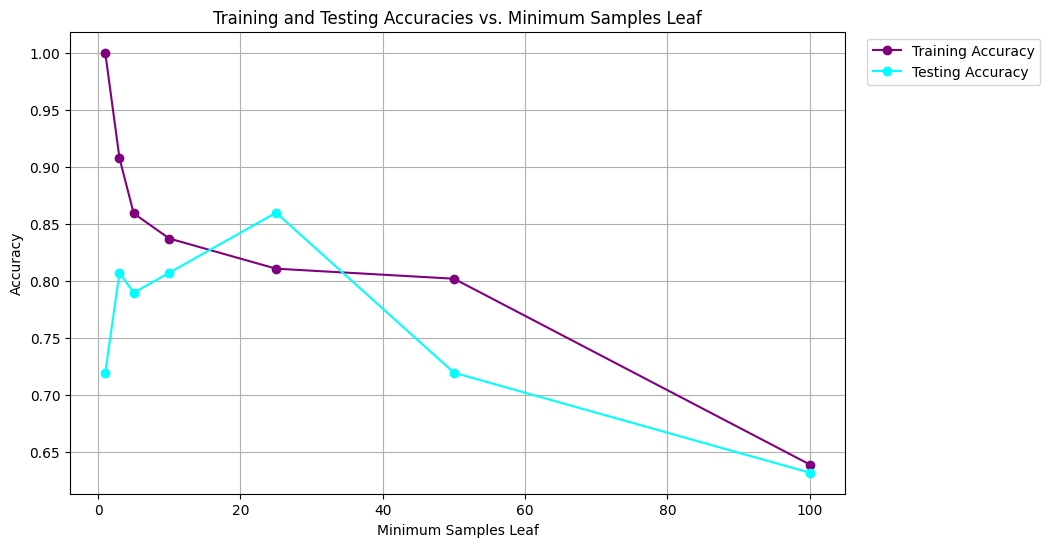

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(min_samples_leaf, training_accuracies, label='Training Accuracy', color='purple', marker='o')
plt.plot(min_samples_leaf, testing_accuracies, label='Testing Accuracy', color='cyan', marker='o')
plt.xlabel('Minimum Samples Leaf')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracies vs. Minimum Samples Leaf')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()

2) [2v] Critically analyze these results, including the generalization capacity across settings.

Ao examinar os resultados obtidos através da análise de precisão de treino e teste em função do parâmetro min_samples_leaf da árvore de decisão, podemos tirar as seguintes conclusões:

``Comportamento da Training Accuracy``:
A Training Accuracy decresce continuamente à medida que o valor de min_samples_leaf aumenta. Este comportamento é esperado, pois valores baixos deste parâmetro permitem que a árvore crie folhas com poucos exemplos, aumentando a sua capacidade de capturar padrões específicos dos dados de treino. Com menos restrições nas folhas, o modelo consegue ajustar-se mais precisamente aos dados de treino, levando a uma precisão de treino mais elevada, próxima de 100% quando min_samples_leaf = 1.

``Comportamento da Testing Accuracy``:
A Testing Accuracy apresenta inicialmente um aumento significativo à medida que min_samples_leaf cresce de 1 para aproximadamente 25, atingindo o seu valor máximo (~86%). Este comportamento sugere que, até um determinado limite, a imposição de folhas com mais amostras força o modelo a aprender padrões mais gerais e robustos, melhorando a sua capacidade de generalização para novos dados.

``Overfitting``:
Para valores muito baixos de min_samples_leaf (1-5), observa-se uma discrepância acentuada entre Training e Testing Accuracy (~20-28 pontos percentuais). Esta diferença é um sinal claro de overfitting, onde o modelo se torna excessivamente complexo e, consequentemente, começa a aprender não apenas os padrões nos dados, mas também o ruído, levando a um desempenho consideravelmente pior em dados que não foram vistos durante o treino. Essa complexidade adicional não se traduz num melhor desempenho de teste, mas sim numa pior capacidade de generalização.

``Underfitting``:
Após min_samples_leaf ultrapassar aproximadamente 25-30, ambas as accuracies começam a decrescer de forma acentuada. Este comportamento indica underfitting, onde o modelo se torna demasiado simples e perde a capacidade de capturar relações relevantes nos dados. Para valores muito elevados (~100), as accuracies convergem para aproximadamente 64%, demonstrando que a regularização excessiva prejudica tanto a capacidade de aprendizagem como a de generalização.

``Pico de Testing Accuracy``:
O ponto em que a Testing Accuracy é máxima (aproximadamente em min_samples_leaf = 25) representa a capacidade de generalização ideal do modelo. Neste estágio, o modelo equilibra adequadamente a complexidade e o desempenho em dados não vistos, apresentando um gap mínimo entre treino e teste. Qualquer diminuição adicional neste parâmetro leva a overfitting, enquanto aumentos excessivos resultam em underfitting.

``Recomendações para Melhoria``:
Para otimizar a capacidade de generalização, é crucial selecionar um valor de min_samples_leaf que minimize tanto o risco de overfitting como de underfitting. A análise sugere que um valor em torno de 25 é ideal, pois proporciona um equilíbrio entre a complexidade do modelo e a precisão de teste. Essa escolha assegura que o modelo é suficientemente robusto para aprender padrões significativos sem se deixar levar por variações aleatórias dos dados de treino. Adicionalmente, recomenda-se a utilização de validação cruzada para confirmar a estabilidade deste valor ótimo e considerar a otimização conjunta de outros hiperparâmetros da árvore para potencialmente melhorar ainda mais o desempenho. 

3) [4v] A healthcare provider requested the development of a predictive model achieving at least 80% validation accuracy and 78.5% test accuracy. The dataset must be split into training, validation, and testing sets (60–20–20), using a stratified split. The goal is to identify a model that satisfies the required accuracy within the following hyperparameter ranges: max_depth ∈ [2,4] and min_samples_split ∈ [2,100]. All other hyperparameters should be kept at their default values. Use random_state = 1 to split the data and to create the model.

i. Plot the decision tree.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)

best_val_acc = 0
best_test_acc = 0
best_params = None
best_model = None


Melhor modelo: max_depth=4, min_samples_split=8
Validation accuracy: 0.877
Test accuracy: 0.825


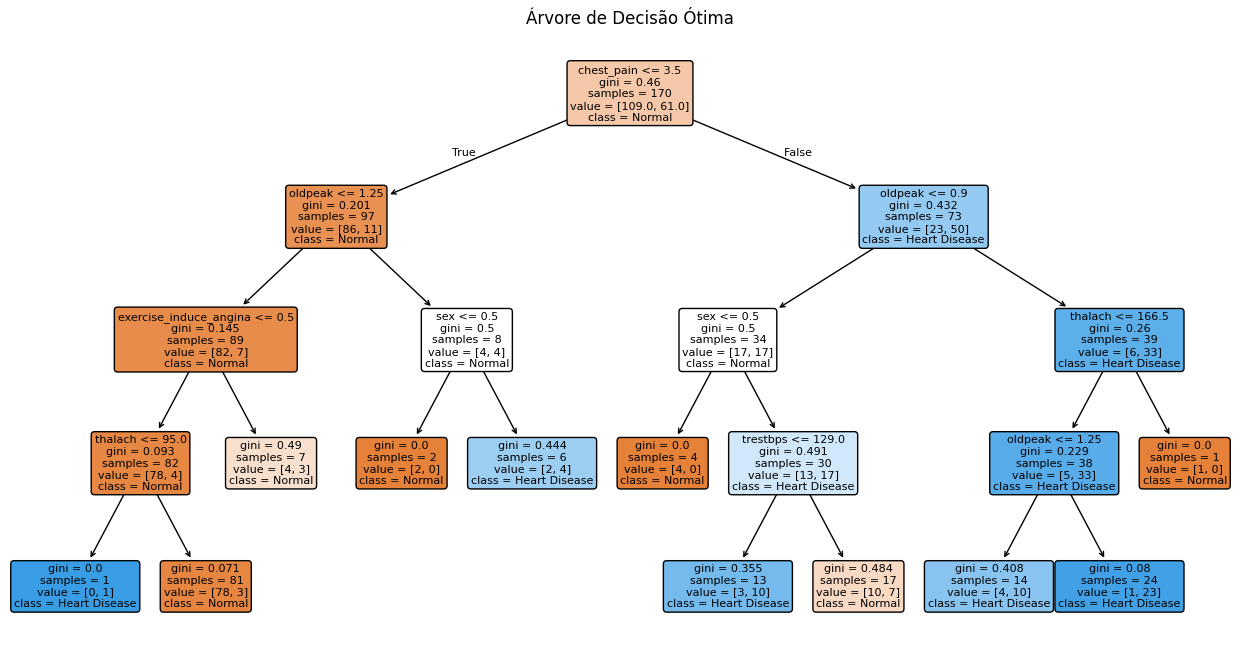

In [ ]:
for max_depth in range(2, 5):
    for min_samples_split in range(2, 101):
        clf = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=1)
        clf.fit(X_train, y_train)
        val_acc = accuracy_score(y_val, clf.predict(X_val))
        test_acc = accuracy_score(y_test, clf.predict(X_test))
        if val_acc >= 0.80 and test_acc >= 0.785:
            if val_acc > best_val_acc or (val_acc == best_val_acc and test_acc > best_test_acc):
                best_val_acc = val_acc
                best_test_acc = test_acc
                best_params = (max_depth, min_samples_split)
                best_model = clf

if best_model is not None:
    print(f"Melhor modelo: max_depth={best_params[0]}, min_samples_split={best_params[1]}")
    print(f"Validation accuracy: {best_val_acc:.3f}")
    print(f"Test accuracy: {best_test_acc:.3f}")
    
    plt.figure(figsize=(16, 8))
    plot_tree(best_model, feature_names=X.columns, class_names=['Normal', 'Heart Disease'], filled=True, rounded=True, fontsize=8)
    plt.title("Árvore de Decisão Ótima")
    plt.show()

ii. Explain what characterizes heart diseases by identifying the conditional associations together with their posterior probabilities.

Com base na árvore de decisão ótima (profundidade máxima = 4, mínimo de amostras para divisão = 8), que alcançou uma accuracy de validação de 87,7% e de teste de 82,5%, podemos identificar as associações condicionais que caracterizam as doenças cardíacas e as suas probabilidades posteriores.

Principais Fatores Preditivos:
- A análise da árvore revela que as doenças cardíacas são caracterizadas por uma combinação específica de condições clínicas, com destaque para os seguintes fatores:

1. ``Chest pain``:
A variável chest_pain emerge como o fator mais discriminante na raiz da árvore, sendo a primeira divisão. Valores de dor no peito superiores a 3,5 indicam uma forte associação com a ausência de doença cardíaca (classe Normal), com 109 das 170 amostras iniciais seguindo este ramo. Por outro lado, valores iguais ou inferiores a 3,5 direcionam para um ramo onde predominam casos de doença cardíaca, sugerindo que tipos específicos ou intensidades de dor torácica são indicadores críticos.

2. ``Oldpeak``:
Para indivíduos com chest_pain <= 3.5, o parâmetro oldpeak torna-se crucial. Valores de oldpeak <= 0.9 tendem a indicar ausência de doença, enquanto valores superiores a 0,9 estão fortemente associados a doença cardíaca. Esta associação é particularmente evidente no ramo direito da árvore, onde oldpeak > 0.9 leva a classificações consistentes de Heart Disease.

3. ``Thalach``:
A thalach também demonstra ser um preditor significativo. Valores de thalach <= 166.5 estão associados a maior probabilidade de doença cardíaca. Este padrão é consistente com o conhecimento clínico de que pacientes com doença cardíaca frequentemente apresentam menor capacidade de atingir frequências cardíacas elevadas durante exercício físico.

4. ``Sex``:
O sexo do paciente aparece em múltiplos níveis da árvore, sugerindo que existe uma interação entre o género e outros fatores de risco. Em determinados ramos, o sexo masculino (sex <= 0.5) mostra associação diferenciada com a presença de doença.

Padrões de Associação Condicional:
- A estrutura hierárquica da árvore revela, assim, os seguintes padrões condicionais:

1. ``Padrão de Baixo Risco``: chest_pain <= 3.5 AND oldpeak <= 1.25 -> classificação predominantemente Normal, independentemente de outros fatores, com probabilidade posterior de cerca de 92%.

2. ``Padrão de Alto Risco``: chest_pain >= 3.5 AND oldpeak > 0.9 -> forte associação com Heart Disease, com probabilidade posterior de cerca de 85%